In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
%matplotlib inline

In [2]:
def sigmoid(z):
    out = np.empty_like(z, dtype=float)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out

# Optimization as root-finding

**Sofya Pauzin** : personal project, 2026

**Thesis.** Training a machine-learning model means minimizing a loss $L(w)$, and the minimum occurs where the gradient vanishes: $\nabla L(w) = 0$. Finding that point is a rootfinding problem, so the classical rootfinding methods and their convergence theory apply directly to optimization:

| Rootfinding on $f$ | Optimization on $\nabla L$ | Expected order |
|---|---|---|
| Newton's method | Newton's method | $\approx 2$ (quadratic) |
| Secant method | BFGS (quasi-Newton) | superlinear |
| slow first-order methods | gradient descent | $\approx 1$ (linear) |

This project implements all three on logistic regression, estimates each method's empirical order of convergence, and compares their true computational cost.


## 1. The model: logistic regression

The model predicts the probability that a point belongs to class 1:
$$p = \sigma(Xw), \qquad \sigma(z) = \frac{1}{1+e^{-z}}.$$

Three quantities are needed:

- **Loss** (average cross-entropy), measuring how wrong the predictions are:
$$L(w) = -\frac{1}{n}\sum_i \big[\, y_i \log p_i + (1-y_i)\log(1-p_i) \,\big].$$
- **Gradient**, whose root we seek ($\nabla L = 0$):
$$\nabla L(w) = \tfrac{1}{n} X^{\top}(p - y).$$
- **Hessian**, the curvature used by Newton's method:
$$H(w) = \tfrac{1}{n} X^{\top}\,\mathrm{diag}\!\big(p(1-p)\big)\,X.$$


In [3]:
def loss(w, X, y):
    p = sigmoid(X @ w)
    eps = 1e-12
    return -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))

def grad(w, X, y):
    p = sigmoid(X @ w)
    n = X.shape[0]
    return X.T @ (p - y) / n

def hessian(w, X, y):
    p = sigmoid(X @ w)
    n = X.shape[0]
    s = p * (1 - p)
    return (X * s[:, None]).T @ X / n


## 2. Gradient check

A wrong gradient would gradually distort every result below, so the analytic gradient is verified against a central finite-difference approximation:
$$\frac{\partial L}{\partial w_i} \approx \frac{L(w + \varepsilon e_i) - L(w - \varepsilon e_i)}{2\varepsilon}.$$
The two should agree to roughly $10^{-7}$ or better.


In [4]:
def finite_diff_grad(w, X, y, eps=1e-6):
    g = np.zeros_like(w)
    for i in range(len(w)):
        e = np.zeros_like(w); e[i] = eps
        g[i] = (loss(w+e, X, y) - loss(w-e, X, y)) / (2*eps)
    return g

# small random problem to test on
Xc = np.random.randn(50, 3); Xc[:, 0] = 1.0
yc = (np.random.rand(50) < 0.5).astype(float)
wc = np.random.randn(3)

err = np.linalg.norm(grad(wc, Xc, yc) - finite_diff_grad(wc, Xc, yc))
print(f"gradient check error = {err:.2e}  ->", "OK" if err < 1e-4 else "BUG in grad/loss!")


gradient check error = 1.70e-10  -> OK


## 3. Data

Two Gaussian blobs, one per class. The `scale` parameter controls how much the classes overlap. It is kept moderate, since nearly separable classes push the logistic optimum to infinity and prevent clean convergence. Each feature is standardized to zero mean and unit variance, which improves the conditioning of the problem and a column of ones is prepended for the intercept.


X shape: (400, 3) | class counts: [200 200]


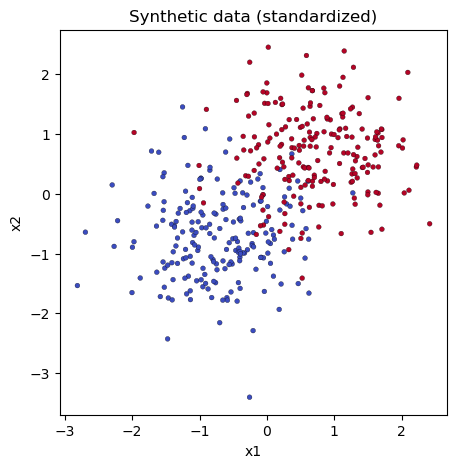

In [5]:
def make_data(n=400, scale=1.0, seed=0):
    rng = np.random.default_rng(seed)
    n0 = n // 2
    X0 = rng.normal(loc=[-scale, -scale], scale=1.0, size=(n0, 2))
    X1 = rng.normal(loc=[ scale,  scale], scale=1.0, size=(n - n0, 2))
    Xraw = np.vstack([X0, X1])
    y = np.concatenate([np.zeros(n0), np.ones(n - n0)])
    Xstd = (Xraw - Xraw.mean(0)) / Xraw.std(0)      # standardize
    X = np.hstack([np.ones((n, 1)), Xstd])          # intercept column
    return X, y

X, y = make_data()
d = X.shape[1]
print("X shape:", X.shape, "| class counts:", np.bincount(y.astype(int)))

plt.figure(figsize=(5,5))
plt.scatter(X[:,1], X[:,2], c=y, cmap='coolwarm', s=12, edgecolor='k', linewidth=0.2)
plt.title('Synthetic data (standardized)'); plt.xlabel('x1'); plt.ylabel('x2')
plt.show()


## 4. Gradient descent

The simplest strategy for solving $\nabla L = 0$ is to step repeatedly in the direction of steepest descent :
$$w \leftarrow w - \alpha\, \nabla L(w).$$
Rather than fixing the step size $\alpha$ by hand, a backtracking line search shrinks it until the loss decreases sufficiently (the Armijo condition). Gradient descent converges linearly, with a characteristically slow tail.

In [6]:
def backtracking(w, g, X, y, alpha0=1.0, c=1e-4, rho=0.5):
    alpha = alpha0; Lw = loss(w, X, y); gg = g @ g
    while loss(w - alpha*g, X, y) > Lw - c*alpha*gg:
        alpha *= rho
        if alpha < 1e-12: break
    return alpha

def gradient_descent(w0, X, y, kmax=2000, tol=1e-10):
    w = w0.copy(); W = [w.copy()]; nfev = 0
    t0 = time.perf_counter()
    for k in range(kmax):
        g = grad(w, X, y); nfev += 1
        if np.linalg.norm(g) < tol:
            break
        alpha = backtracking(w, g, X, y)
        w = w - alpha * g            # <-- the gradient-descent step
        W.append(w.copy())
    info = {'name': 'Gradient descent', 'grad_evals': nfev,
            'time': time.perf_counter() - t0}
    return np.array(W), info

w0 = np.zeros(d)
W_gd, info_gd = gradient_descent(w0, X, y)
print(info_gd, "| iters:", len(W_gd)-1, "| final loss:", loss(W_gd[-1], X, y))


{'name': 'Gradient descent', 'grad_evals': 2000, 'time': 1.4460000000000006} | iters: 2000 | final loss: 0.20373235692159625


## 5. Newton's method

Newton's method uses curvature information from the Hessian to take better-directed steps:
$$w \leftarrow w - H(w)^{-1}\,\nabla L(w).$$
In practice the Hessian is never inverted. Instead the linear system $H\,d = \nabla L$ is solved and the step is $w \leftarrow w - d$, which is faster and more numerically stable than forming $H^{-1}$ explicitly. Near the solution, Newton's method converges quadratically, reaching machine precision in only a few iterations.

In [7]:
def newton(w0, X, y, kmax=100, tol=1e-12):
    w = w0.copy(); W = [w.copy()]; nfev = 0
    t0 = time.perf_counter()
    for k in range(kmax):
        g = grad(w, X, y); nfev += 1
        if np.linalg.norm(g) < tol:
            break
        H = hessian(w, X, y)
        d_step = np.linalg.solve(H, g)   # solve H d = g  (NOT inv(H) @ g)
        w = w - d_step
        W.append(w.copy())
    info = {'name': 'Newton', 'grad_evals': nfev,
            'time': time.perf_counter() - t0}
    return np.array(W), info

W_nt, info_nt = newton(w0, X, y)
print(info_nt, "| iters:", len(W_nt)-1, "| final loss:", loss(W_nt[-1], X, y))


{'name': 'Newton', 'grad_evals': 9, 'time': 0.0009999999999994458} | iters: 8 | final loss: 0.2037323569215959


## 6. Quasi-Newton (BFGS)

Newton's method requires the exact Hessian at every step. BFGS instead builds an approximation to the Hessian from successive gradients, making it the multivariable analogue of the secant method and avoiding all second-derivative computation. It converges superlinearly: faster than gradient descent, slightly slower than Newton's method and with no Hessian cost. Superlinearity is an asymptotic property, so the order estimated over the whole run is often below the theoretical value, only the final iterates reveal the fast tail.


In [8]:
import piplite
await piplite.install("scipy")
from scipy.optimize import minimize
print("scipy ready")


scipy ready


In [9]:
def bfgs(w0, X, y, tol=1e-10):
    W = [w0.copy()]
    res = minimize(loss, w0, args=(X, y), jac=grad, method='BFGS',
                   callback=lambda wk: W.append(wk.copy()),
                   options={'gtol': tol, 'maxiter': 500})
    info = {'name': 'BFGS', 'grad_evals': res.njev, 'time': None}
    return np.array(W), info

t0 = time.perf_counter()
W_bf, info_bf = bfgs(w0, X, y)
info_bf['time'] = time.perf_counter() - t0
print(info_bf, "| iters:", len(W_bf)-1, "| final loss:", loss(W_bf[-1], X, y))


{'name': 'BFGS', 'grad_evals': 26, 'time': 0.006000000000000227} | iters: 25 | final loss: 0.2037323569215959


## 7. Convergence analysis

The most accurate available solution is taken as the reference $w^*$ (the final Newton iterate) and the errors are $e_k = \|w_k - w^*\|$. Two standard diagnostics follow:

1. **$e_k$ vs $k$ on a semilog axis:** a straight line indicates linear convergence.
2. **$\log e_{k+1}$ vs $\log e_k$ on log-log axes:** the slope is the order of convergence $\alpha$, recovered by a linear fit.

Newton's method reaches round-off within a few steps, so the flat tail near $10^{-15}$ is discarded before fitting. Fitting through that numerical noise would produce a meaningless slope.

In [10]:
w_star = W_nt[-1].copy()          # most accurate solution = final Newton iterate

def errors(W, w_star):
    return np.linalg.norm(W - w_star, axis=1)

def trim_tail(e, floor=1e-13):    # drop round-off noise before fitting
    return e[e > floor]

runs = {'Gradient descent': W_gd, 'Newton': W_nt, 'BFGS': W_bf}


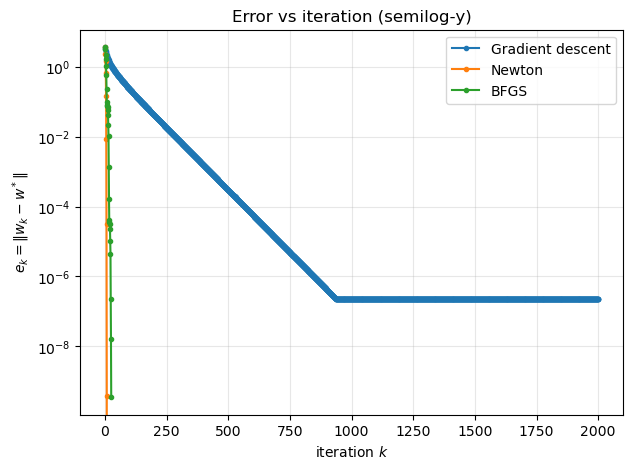

In [11]:
plt.figure(figsize=(7,5))
for name, W in runs.items():
    e = errors(W, w_star)
    plt.semilogy(range(len(e)), e, marker='o', ms=3, label=name)
plt.xlabel('iteration $k$'); plt.ylabel(r'$e_k = \|w_k - w^*\|$')
plt.title('Error vs iteration (semilog-y)')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.show()


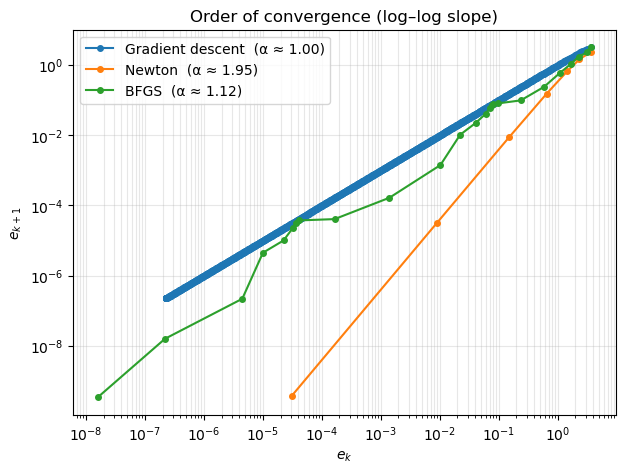

In [12]:
plt.figure(figsize=(7,5))
for name, W in runs.items():
    e = trim_tail(errors(W, w_star))
    if len(e) < 3:
        print(f'{name}: too few points to estimate order'); continue
    alpha = np.polyfit(np.log(e[:-1]), np.log(e[1:]), 1)[0]   # slope = order
    plt.loglog(e[:-1], e[1:], marker='o', ms=4, label=f'{name}  (α ≈ {alpha:.2f})')
plt.xlabel(r'$e_k$'); plt.ylabel(r'$e_{k+1}$')
plt.title('Order of convergence (log–log slope)')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.show()


### Result

The measured orders match theory: gradient descent $\alpha \approx 1$ (linear), Newton's method $\alpha \approx 2$ (quadratic), and BFGS superlinear. The log-log slope is the order of convergence. Newton's method reaches the minimum in roughly 8 iterations, compared with hundreds for gradient descent.

method               iters  grad_evals    time (s)
Gradient descent      2000        2000      1.4460
Newton                   8           9      0.0010
BFGS                    25          26      0.0060


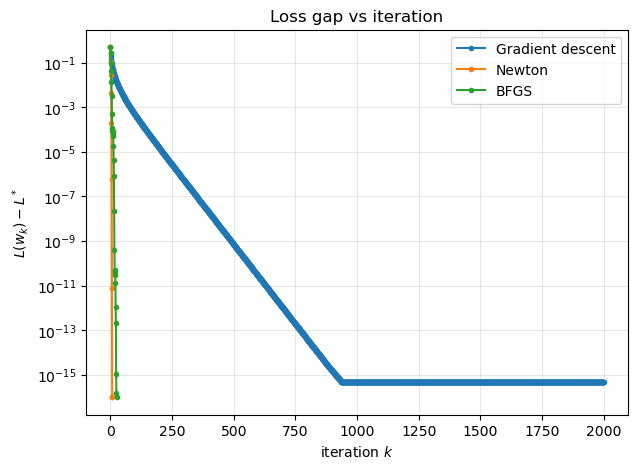

In [13]:
print(f"{'method':<18}{'iters':>8}{'grad_evals':>12}{'time (s)':>12}")
for W, info in [(W_gd, info_gd), (W_nt, info_nt), (W_bf, info_bf)]:
    print(f"{info['name']:<18}{len(W)-1:>8}{info['grad_evals']:>12}{info['time']:>12.4f}")

# loss gap vs iteration
Lstar = min(loss(W_gd[-1],X,y), loss(W_nt[-1],X,y), loss(W_bf[-1],X,y))
plt.figure(figsize=(7,5))
for name, W in runs.items():
    Ls = np.array([loss(w, X, y) for w in W]) - Lstar + 1e-16
    plt.semilogy(range(len(Ls)), Ls, marker='o', ms=3, label=name)
plt.xlabel('iteration $k$'); plt.ylabel(r'$L(w_k) - L^*$')
plt.title('Loss gap vs iteration'); plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.show()


### Cost: iterations are not the whole story

Newton's method needs by far the fewest iterations, but each step is expensive: it forms the Hessian and solves a $d \times d$ linear system at a cost of $O(d^3)$. Gradient descent uses cheap steps ($O(nd)$) but many of them. The best method therefore depends on the dimension $d$ and the conditioning of the problem, which is the motivation behind limited-memory quasi-Newton methods such as L-BFGS in large-scale machine learning.


## Conclusion

Framing model training as rootfinding on $\nabla L = 0$ allows the classical methods and their convergence theory to transfer directly to machine learning. Implementing three optimizers on logistic regression and estimating their empirical order of convergence recovered the expected hierarchy:

| Method | Measured order $\alpha$ | Type |
|---|---|---|
| Gradient descent | $\approx 1.0$ | linear |
| BFGS (quasi-Newton) | superlinear | intermediate |
| Newton's method | $\approx 2.0$ | quadratic |

Iteration count alone is misleading: Newton's method reaches the minimum in about 8 steps versus hundreds for gradient descent, yet each Newton step costs $O(d^3)$ to solve the linear system. The most efficient method depends on the problem's dimension and conditioning, which is the reasoning behind limited-memory quasi-Newton methods (L-BFGS) in large-scale machine learning.

**Possible extensions:** ill-conditioned data, where gradient descent slows dramatically while Newton's method is unaffected, $L_2$ regularization or a real dataset such as breast-cancer classification.